In [75]:
from obspy.clients.fdsn import Client
import obspy
import matplotlib.pyplot as plt
import re
import pandas as pd
from glob import glob
import argparse
from datetime import datetime


from datetime import datetime, timedelta


In [76]:
matched_files = glob(f'logs/*20251201*20251217*')

if not matched_files:
    raise FileNotFoundError("No event files found overlapping the requested time range")


print(f"Found {len(matched_files)} event files")





# Load each into a DataFrame
dfs = [pd.read_csv(f) for f in matched_files]


Found 62 event files


In [77]:
# Combine all station events into one DataFrame
df_all = pd.concat(dfs, ignore_index=True)
print(df_all.head())

  station network class        auc  mean_prob  max_prob  start_index  \
0    CRYS      CC    eq   6.025899   0.363125  0.785621         7835   
1    CRYS      CC    eq   2.993197   0.348157  0.586463         8012   
2    CRYS      CC    eq  10.315415   0.306568  0.510860         8032   
3    CRYS      CC    eq   2.841140   0.331027  0.540440         8391   
4    CRYS      CC    eq   2.657580   0.311593  0.500393        15597   

   end_index                   start_time                     end_time  
0       7851  2025-12-01T21:46:40.000000Z  2025-12-01T21:49:20.000000Z  
1       8020  2025-12-01T22:16:10.000000Z  2025-12-01T22:17:30.000000Z  
2       8065  2025-12-01T22:19:30.000000Z  2025-12-01T22:25:00.000000Z  
3       8399  2025-12-01T23:19:20.000000Z  2025-12-01T23:20:40.000000Z  
4      15605  2025-12-02T19:20:20.000000Z  2025-12-02T19:21:40.000000Z  


In [78]:
df_all

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time
0,CRYS,CC,eq,6.025899,0.363125,0.785621,7835,7851,2025-12-01T21:46:40.000000Z,2025-12-01T21:49:20.000000Z
1,CRYS,CC,eq,2.993197,0.348157,0.586463,8012,8020,2025-12-01T22:16:10.000000Z,2025-12-01T22:17:30.000000Z
2,CRYS,CC,eq,10.315415,0.306568,0.510860,8032,8065,2025-12-01T22:19:30.000000Z,2025-12-01T22:25:00.000000Z
3,CRYS,CC,eq,2.841140,0.331027,0.540440,8391,8399,2025-12-01T23:19:20.000000Z,2025-12-01T23:20:40.000000Z
4,CRYS,CC,eq,2.657580,0.311593,0.500393,15597,15605,2025-12-02T19:20:20.000000Z,2025-12-02T19:21:40.000000Z
...,...,...,...,...,...,...,...,...,...,...
59635,STAR,UW,su,2.646527,0.306701,0.520457,930,938,2025-12-15T16:06:33.750000Z,2025-12-15T16:07:53.750000Z
59636,STAR,UW,su,9.040607,0.434445,0.704604,1494,1514,2025-12-15T17:40:33.750000Z,2025-12-15T17:43:53.750000Z
59637,STAR,UW,su,5.013030,0.341078,0.500669,1672,1686,2025-12-15T18:10:13.750000Z,2025-12-15T18:12:33.750000Z
59638,STAR,UW,su,2.465887,0.328996,0.532194,2042,2049,2025-12-17T00:09:24.798000Z,2025-12-17T00:10:34.798000Z


In [79]:
df_all[df_all['station'] == 'CRYS'].sort_values('start_time').head(10)

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time
366,CRYS,CC,su,10.909949,0.552942,0.895295,519,538,2025-12-01T01:27:20.000000Z,2025-12-01T01:30:30.000000Z
367,CRYS,CC,su,6.486574,0.510292,0.915563,542,554,2025-12-01T01:31:10.000000Z,2025-12-01T01:33:10.000000Z
368,CRYS,CC,su,7.207364,0.490621,0.805794,677,691,2025-12-01T01:53:40.000000Z,2025-12-01T01:56:00.000000Z
369,CRYS,CC,su,7.740511,0.527099,0.895017,2372,2386,2025-12-01T06:36:10.000000Z,2025-12-01T06:38:30.000000Z
370,CRYS,CC,su,3.598118,0.374672,0.607102,2473,2482,2025-12-01T06:53:00.000000Z,2025-12-01T06:54:30.000000Z
371,CRYS,CC,su,6.207524,0.453702,0.817105,2534,2547,2025-12-01T07:03:10.000000Z,2025-12-01T07:05:20.000000Z
372,CRYS,CC,su,8.102656,0.516980,0.916763,2583,2598,2025-12-01T07:11:20.000000Z,2025-12-01T07:13:50.000000Z
373,CRYS,CC,su,5.048423,0.432643,0.783302,2726,2737,2025-12-01T07:35:10.000000Z,2025-12-01T07:37:00.000000Z
374,CRYS,CC,su,4.844530,0.311233,0.574268,5727,5742,2025-12-01T15:55:20.000000Z,2025-12-01T15:57:50.000000Z
375,CRYS,CC,su,6.747512,0.345244,0.571146,6093,6112,2025-12-01T16:56:20.000000Z,2025-12-01T16:59:30.000000Z


In [80]:
# Convert start_time to datetime if it's not already
df_all["start_time"] = pd.to_datetime(df_all["start_time"])

In [81]:
# Round to nearest 10s window (you can try 5s or 15s too)
df_all["rounded_start"] = df_all["start_time"].dt.round("10s")

In [82]:
df_all

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time,rounded_start
0,CRYS,CC,eq,6.025899,0.363125,0.785621,7835,7851,2025-12-01 21:46:40+00:00,2025-12-01T21:49:20.000000Z,2025-12-01 21:46:40+00:00
1,CRYS,CC,eq,2.993197,0.348157,0.586463,8012,8020,2025-12-01 22:16:10+00:00,2025-12-01T22:17:30.000000Z,2025-12-01 22:16:10+00:00
2,CRYS,CC,eq,10.315415,0.306568,0.510860,8032,8065,2025-12-01 22:19:30+00:00,2025-12-01T22:25:00.000000Z,2025-12-01 22:19:30+00:00
3,CRYS,CC,eq,2.841140,0.331027,0.540440,8391,8399,2025-12-01 23:19:20+00:00,2025-12-01T23:20:40.000000Z,2025-12-01 23:19:20+00:00
4,CRYS,CC,eq,2.657580,0.311593,0.500393,15597,15605,2025-12-02 19:20:20+00:00,2025-12-02T19:21:40.000000Z,2025-12-02 19:20:20+00:00
...,...,...,...,...,...,...,...,...,...,...,...
59635,STAR,UW,su,2.646527,0.306701,0.520457,930,938,2025-12-15 16:06:33.750000+00:00,2025-12-15T16:07:53.750000Z,2025-12-15 16:06:30+00:00
59636,STAR,UW,su,9.040607,0.434445,0.704604,1494,1514,2025-12-15 17:40:33.750000+00:00,2025-12-15T17:43:53.750000Z,2025-12-15 17:40:30+00:00
59637,STAR,UW,su,5.013030,0.341078,0.500669,1672,1686,2025-12-15 18:10:13.750000+00:00,2025-12-15T18:12:33.750000Z,2025-12-15 18:10:10+00:00
59638,STAR,UW,su,2.465887,0.328996,0.532194,2042,2049,2025-12-17 00:09:24.798000+00:00,2025-12-17T00:10:34.798000Z,2025-12-17 00:09:20+00:00


In [84]:
df_all[df_all['station'] == 'CRYS'].sort_values("start_time")

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time,rounded_start
366,CRYS,CC,su,10.909949,0.552942,0.895295,519,538,2025-12-01 01:27:20+00:00,2025-12-01T01:30:30.000000Z,2025-12-01 01:27:20+00:00
367,CRYS,CC,su,6.486574,0.510292,0.915563,542,554,2025-12-01 01:31:10+00:00,2025-12-01T01:33:10.000000Z,2025-12-01 01:31:10+00:00
368,CRYS,CC,su,7.207364,0.490621,0.805794,677,691,2025-12-01 01:53:40+00:00,2025-12-01T01:56:00.000000Z,2025-12-01 01:53:40+00:00
369,CRYS,CC,su,7.740511,0.527099,0.895017,2372,2386,2025-12-01 06:36:10+00:00,2025-12-01T06:38:30.000000Z,2025-12-01 06:36:10+00:00
370,CRYS,CC,su,3.598118,0.374672,0.607102,2473,2482,2025-12-01 06:53:00+00:00,2025-12-01T06:54:30.000000Z,2025-12-01 06:53:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...
1259,CRYS,CC,su,6.867678,0.349995,0.677255,10353,10372,2025-12-17 08:34:54.433333+00:00,2025-12-17T08:38:04.433333Z,2025-12-17 08:34:50+00:00
1260,CRYS,CC,su,5.109634,0.276390,0.509846,10378,10396,2025-12-17 08:39:04.433333+00:00,2025-12-17T08:42:04.433333Z,2025-12-17 08:39:00+00:00
1261,CRYS,CC,su,10.611117,0.336654,0.643121,10456,10487,2025-12-17 08:52:04.433333+00:00,2025-12-17T08:57:14.433333Z,2025-12-17 08:52:00+00:00
1262,CRYS,CC,su,5.074332,0.400337,0.767093,10488,10500,2025-12-17 08:57:24.433333+00:00,2025-12-17T08:59:24.433333Z,2025-12-17 08:57:20+00:00


In [87]:
df_all[df_all['station'] == 'RCM'].sort_values('rounded_start')

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time,rounded_start
18995,RCM,UW,eq,8.857457,0.565469,0.949042,0,15,2025-12-01 00:00:50.002857+00:00,2025-12-01T00:03:20.002857Z,2025-12-01 00:00:50+00:00
18996,RCM,UW,eq,21.082345,0.558793,0.883143,17,54,2025-12-01 00:03:40.002857+00:00,2025-12-01T00:09:50.002857Z,2025-12-01 00:03:40+00:00
18997,RCM,UW,eq,14.647811,0.391008,0.884535,56,93,2025-12-01 00:10:10.002857+00:00,2025-12-01T00:16:20.002857Z,2025-12-01 00:10:10+00:00
18998,RCM,UW,eq,7.420054,0.444353,0.767176,102,118,2025-12-01 00:17:50.002857+00:00,2025-12-01T00:20:30.002857Z,2025-12-01 00:17:50+00:00
21263,RCM,UW,px,2.949564,0.397273,0.611478,130,137,2025-12-01 00:22:30.002857+00:00,2025-12-01T00:23:40.002857Z,2025-12-01 00:22:30+00:00
...,...,...,...,...,...,...,...,...,...,...,...
24038,RCM,UW,su,5.828657,0.332295,0.650588,143261,143278,2025-12-17 13:57:40.002857+00:00,2025-12-17T14:00:30.002857Z,2025-12-17 13:57:40+00:00
24039,RCM,UW,su,19.744051,0.602730,0.981488,143305,143337,2025-12-17 14:05:00.002857+00:00,2025-12-17T14:10:20.002857Z,2025-12-17 14:05:00+00:00
21260,RCM,UW,eq,3.449788,0.361598,0.534612,143330,143339,2025-12-17 14:09:10.002857+00:00,2025-12-17T14:10:40.002857Z,2025-12-17 14:09:10+00:00
21261,RCM,UW,eq,4.069244,0.351871,0.560999,143341,143352,2025-12-17 14:11:00.002857+00:00,2025-12-17T14:12:50.002857Z,2025-12-17 14:11:00+00:00


In [ ]:
# daily_detection.py

import os
import json
import csv
import numpy as np
import torch
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import pandas as pd
import argparse
from obspy import UTCDateTime

from utils.detect import smooth_moving_avg, detect_event_windows


import sys
sys.path.append('/home/ak287/seisbench/seisbench/models')
import seisbench.models as sbm


##
### 1. `daily_detection.py`

"""**Purpose:** Detect events at individual stations for a given time window.

**Workflow:**

1. **Load model & stations**:

   * Loads a pre-trained QuakeXNet model.
   * Loads a list of seismic stations from `stations.json`.
   * Defines a time window (default = past 24 hours), which can be customized.

2. **Download waveform data**:

   * Fetches continuous waveform data from IRIS for each station using ObsPy.

3. **Run model inference**:

   * Sliding window: **100 s length**, **10 s stride**.
   * Produces **class probabilities** for each window: `eq` (earthquake), `px` (explosion/phase), `su` (surface event), sampled every 10 s.

4. **Smooth probabilities**:

   * 5-sample moving average (~50 s) removes isolated spikes and short noise fluctuations.

5. **Detect events**:

   * Event **starts** when smoothed probability ≥ 0.15.
   * Event **ends** when smoothed probability < 0.15.
   * Event is only logged if **max probability ≥ 0.5** (default).
   * For each event, metrics are recorded: **mean probability**, **max probability**, **area under curve (AUC)**, start/end indices, and corresponding UTC timestamps.

**Output:**

* One CSV per station, with detected events and metrics. Example:

| station | network | class | auc  | mean_prob | max_prob | start_index | end_index | start_time           | end_time             |
| ------- | ------- | ----- | ---- | --------- | -------- | ----------- | --------- | -------------------- | -------------------- |
| PARA    | CC      | eq    | 3.37 | 0.35      | 0.54     | 5429        | 5438      | 2025-12-13T14:44:22Z | 2025-12-13T14:45:52Z |
| PARA    | CC      | eq    | 7.02 | 0.60      | 0.96     | 5561        | 5572      | 2025-12-13T15:06:22Z | 2025-12-13T15:08:12Z |

---"""

## running example - python custom_daily_detection.py  --start 2025-12-10T00:00:00  --end   2025-12-10T23:59:59


# -------------------- User Inputs --------------------
parser = argparse.ArgumentParser(description="Run QuakeXNet event detection on custom time range.")
parser.add_argument("--start", type=str, required=True,
                    help="Start time in UTC (e.g., '2025-12-10T00:00:00')")
parser.add_argument("--end", type=str, required=True,
                    help="End time in UTC (e.g., '2025-12-10T23:59:59')")
args = parser.parse_args()

st_time = UTCDateTime(args.start)
et_time = UTCDateTime(args.end)

print(f"Running detection from {st_time} to {et_time} ({et_time-st_time} seconds)")


# -------------------- Setup --------------------

# Load model
model = sbm.QuakeXNet.from_pretrained("base", version_str = '3')


# Load station list
with open("stations.json", "r") as f:
    stations = json.load(f)

# Create output folders
os.makedirs("plots", exist_ok=True)
os.makedirs("logs", exist_ok=True)
log_file = "logs/detections.csv"

# Write header to CSV if not exists
if not os.path.exists(log_file):
    with open(log_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["date", "station", "final_label", "eq_auc", "px_auc", "su_auc"])





# -------------------- Main Loop --------------------

client = Client("IRIS")
chn_prefix = "QuakeXNet_"
class_names = ['eq', 'px', 'su']
channel_map = {cls: f"{chn_prefix}{cls}" for cls in class_names}

for entry in stations:
    net = entry["net"]
    sta = entry["sta"]
    chn = entry.get("chn", "*H")

    print(f"🔍 Processing {net}.{sta}...")

    try:
        st = client.get_waveforms(
            network=net,
            station=sta,
            channel=chn + "*",
            location="*",
            starttime=st_time,
            endtime=et_time,
        )

        # Run inference
        probs_st = model.annotate(st, stride=500)

        total_auc = {}
        mean_probs = {}
        max_probs = {}
        start = {}
        end = {}

        for cls in class_names:
            total_auc[cls] = []
            mean_probs[cls] = []
            max_probs[cls] = []
            start[cls] = []
            end[cls] = []

            probs = probs_st.select(channel=channel_map[cls])

            for prob in probs:
                probs_array = np.array(prob)
                s_cls = smooth_moving_avg(probs_array)
                events = detect_event_windows(s_cls)

                for event in events:
                    total_auc[cls].append(event['area_under_curve'])
                    mean_probs[cls].append(event['mean_prob'])
                    max_probs[cls].append(event['max_prob'])
                    start[cls].append(event['start'])
                    end[cls].append(event['end'])
            
            
        
        event_records = []

        for cls in class_names:
            for i in range(len(total_auc[cls])):
                start_idx = start[cls][i]
                end_idx = end[cls][i]
                event_start_time = st_time + (start_idx * 500 / 50)  # stride=500, sampling=50Hz
                event_end_time = st_time + (end_idx * 500 / 50)

                event_records.append({
                    "station": sta,
                    "network": net,
                    "class": cls,
                    "auc": total_auc[cls][i],
                    "mean_prob": mean_probs[cls][i],
                    "max_prob": max_probs[cls][i],
                    "start_index": start_idx,
                    "end_index": end_idx,
                    "start_time": str(event_start_time),
                    "end_time": str(event_end_time),
                })

        # Convert to DataFrame
        if event_records:
            df_events = pd.DataFrame(event_records)
            print(df_events)

            # Optionally save it to CSV
            
            # Format start and end times as YYYYMMDD_HHMM
            start_str = st_time.strftime("%Y%m%d_%H%M")
            end_str   = et_time.strftime("%Y%m%d_%H%M")

            # Save CSV with start and end times in filename
            df_events.to_csv(f"logs/{sta}_{start_str}_to_{end_str}_events.csv", index=False)

       



    except Exception as e:
        print(f"❌ Error processing {net}.{sta}: {e}")

In [140]:
import os
import json
import csv
import numpy as np
import torch
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import pandas as pd
import argparse
from obspy import UTCDateTime

from utils.detect import smooth_moving_avg, detect_event_windows


import sys
sys.path.append('/home/ak287/seisbench/seisbench/models')
import seisbench.models as sbm




# Load model
model = sbm.QuakeXNet.from_pretrained("base", version_str = '3')

# -------------------- Main Loop --------------------

client = Client("IRIS")
chn_prefix = "QuakeXNet_"
class_names = ['eq', 'px', 'su']
channel_map = {cls: f"{chn_prefix}{cls}" for cls in class_names}


net = 'UW'
sta = 'RCM'
chn = 'HH'
st_time = obspy.UTCDateTime(2025, 12, 1, 0, 0, 50) - 100
et_time = st_time + 300
st = client.get_waveforms(
            network=net,
            station=sta,
            channel=chn + "*",
            location="*",
            starttime=st_time,
            endtime=et_time,
        )

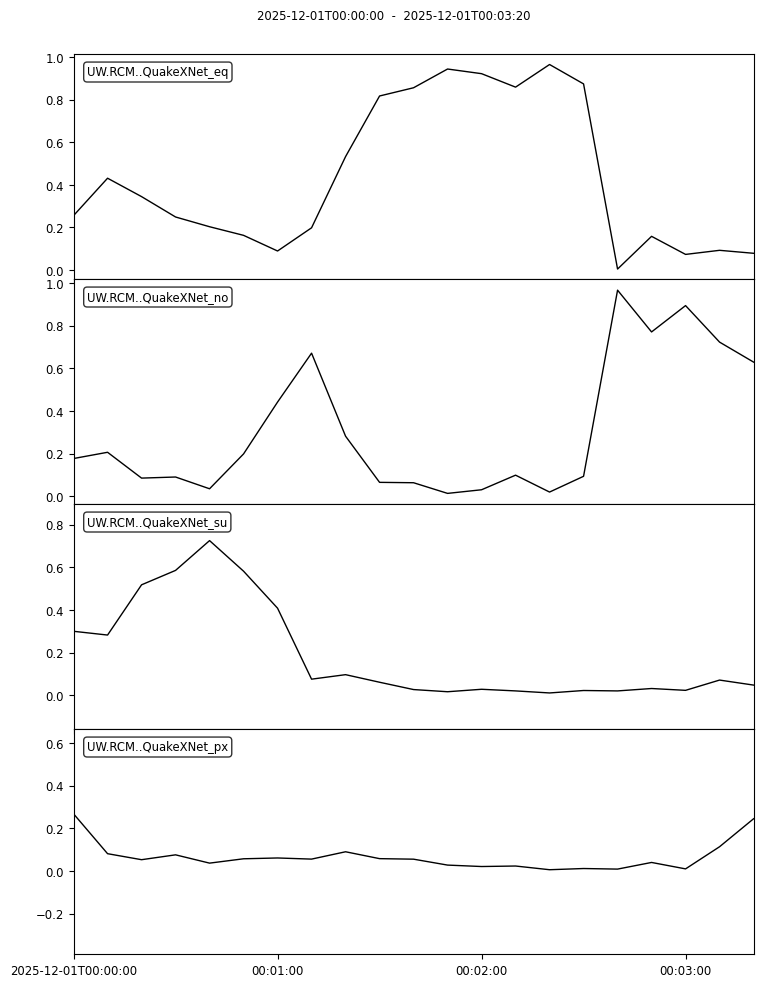

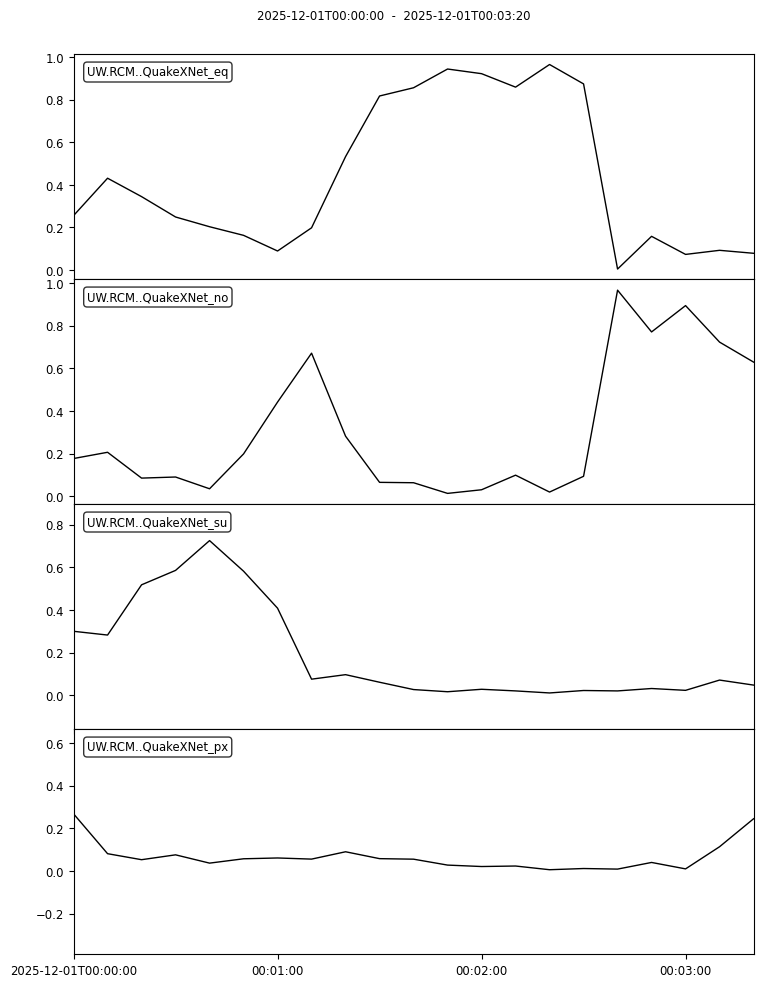

In [141]:
st.resample(50)
probs_st = model.annotate(st, stride=500)

probs_st.plot()

In [137]:
probs_st[0].stats.sampling_rate

0.1

In [138]:
total_auc = {}
mean_probs = {}
max_probs = {}
start = {}
end = {}

for cls in class_names:
    total_auc[cls] = []
    mean_probs[cls] = []
    max_probs[cls] = []
    start[cls] = []
    end[cls] = []

    probs = probs_st.select(channel=channel_map[cls])

    for prob in probs:
        probs_array = np.array(prob)
        s_cls = smooth_moving_avg(probs_array)
        events = detect_event_windows(s_cls)

        for event in events:
            total_auc[cls].append(event['area_under_curve'])
            mean_probs[cls].append(event['mean_prob'])
            max_probs[cls].append(event['max_prob'])
            start[cls].append(event['start'])
            end[cls].append(event['end'])



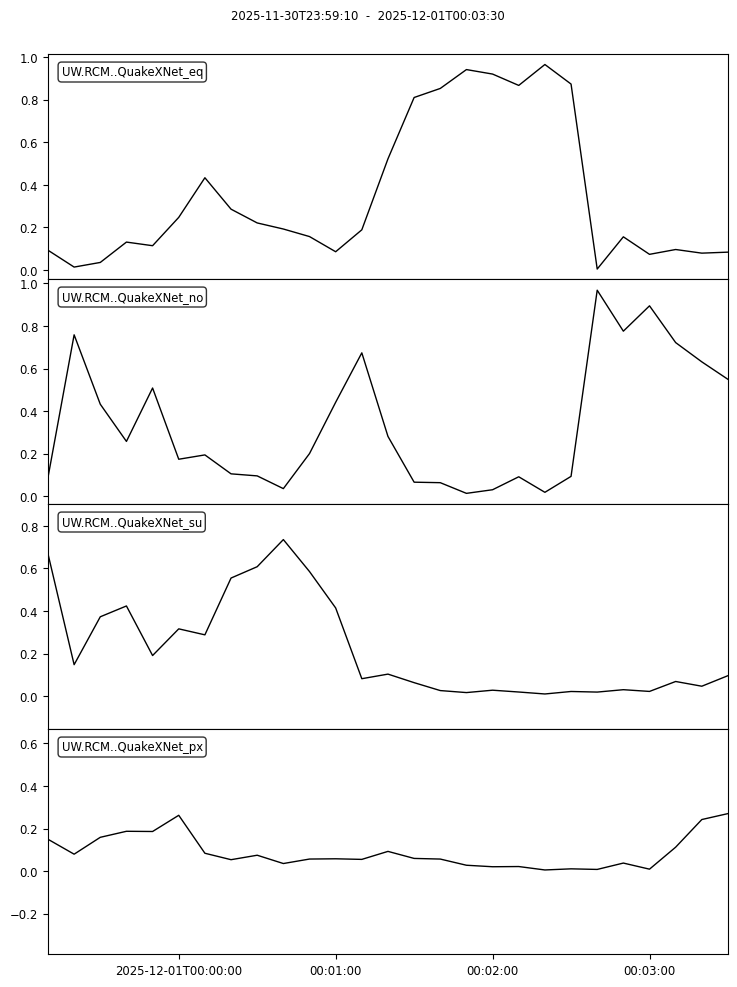

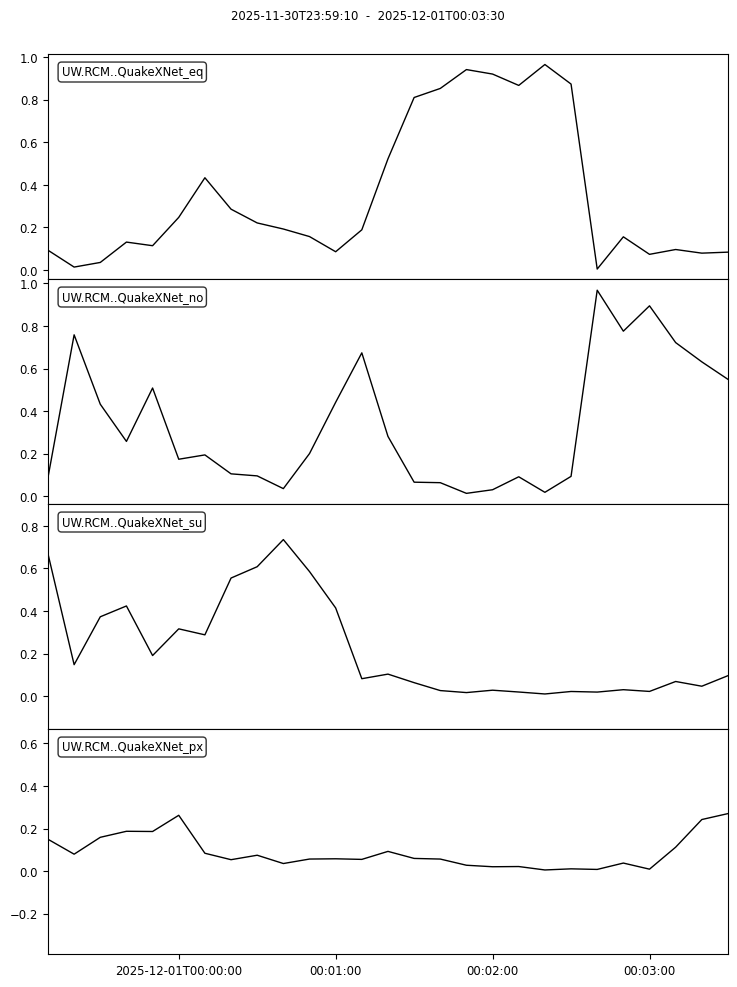

In [139]:
probs_st.plot()

In [119]:
events

[]

In [120]:
total_auc

{'eq': [8.857457445934415, 5.9111843153834345], 'px': [], 'su': []}

In [121]:
len(total_auc['px
              '])

SyntaxError: EOL while scanning string literal (1538973669.py, line 1)

In [122]:
event_records = []
SECONDS_PER_STEP = 10  # stride=500 samples @ 50 Hz

for cls in class_names:
    probs = probs_st.select(channel=channel_map[cls])

    for prob in probs:
        trace_start = prob.stats.starttime
        probs_array = prob.data

        s_cls = smooth_moving_avg(probs_array)
        events = detect_event_windows(s_cls)

        for event in events:
            start_idx = event["start"]
            end_idx   = event["end"]

            event_start_time = trace_start + start_idx * SECONDS_PER_STEP
            event_end_time   = trace_start + end_idx   * SECONDS_PER_STEP

            # optional safety filter
            if event_end_time < st_time or event_start_time > et_time:
                continue

            event_records.append({
                "station": sta,
                "network": net,
                "class": cls,
                "auc": event["area_under_curve"],
                "mean_prob": event["mean_prob"],
                "max_prob": event["max_prob"],
                "start_index": start_idx,
                "end_index": end_idx,
                "start_time": str(event_start_time),
                "end_time": str(event_end_time),
            })


In [69]:
event_records

[{'station': 'CRYS',
  'network': 'CC',
  'class': 'eq',
  'auc': 6.025898890104146,
  'mean_prob': 0.3631245240130845,
  'max_prob': 0.7856209635734558,
  'start_index': 7835,
  'end_index': 7851,
  'start_time': '2025-12-01T21:46:40.000000Z',
  'end_time': '2025-12-01T21:49:20.000000Z'},
 {'station': 'CRYS',
  'network': 'CC',
  'class': 'eq',
  'auc': 2.993196576461196,
  'mean_prob': 0.34815745188130276,
  'max_prob': 0.5864631652832032,
  'start_index': 8012,
  'end_index': 8020,
  'start_time': '2025-12-01T22:16:10.000000Z',
  'end_time': '2025-12-01T22:17:30.000000Z'},
 {'station': 'CRYS',
  'network': 'CC',
  'class': 'eq',
  'auc': 10.3154152110219,
  'mean_prob': 0.30656823458917,
  'max_prob': 0.5108596920967102,
  'start_index': 8032,
  'end_index': 8065,
  'start_time': '2025-12-01T22:19:30.000000Z',
  'end_time': '2025-12-01T22:25:00.000000Z'},
 {'station': 'CRYS',
  'network': 'CC',
  'class': 'eq',
  'auc': 2.8411399934440853,
  'mean_prob': 0.3310265171031157,
  'max_p